In [7]:
import sys
!{sys.executable} -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 16.2 MB/s  0:00:0016.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 20.5 MB/s  0:00:00 21.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/Users/benjaminding/Library/Python/3.9/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]━━━━━━━━━━━ 2/3 [pandas]


In [8]:
import sys
print(sys.executable)

/Applications/Xcode.app/Contents/Developer/usr/bin/python3


In [11]:
import pandas 

In [12]:
df = pandas.read_csv('clean_data.csv')

In [13]:
print(df.head())
print("Dataframe Size:", df.shape)

             id       screen_name                   location  \
0  8.160000e+17  "HoustonPokeMap"              "Houston, TX"   
1  4.843621e+09         kernyeahx  Templeville town, MD, USA   
2  4.303727e+09   mattlieberisbot                        NaN   
3  3.063139e+09         sc_papers                        NaN   
4  2.955142e+09      lucarivera16      Dublin, United States   

                                         description  \
0  "Rare and strong PokŽmon in Houston, TX. See m...   
1  From late 2014 Socium Marketplace will make sh...   
2  Inspired by the smart, funny folks at @replyal...   
3                                                NaN   
4             Inspiring cooks everywhere since 1956.   

                         url  followers_count  friends_count  listed_count  \
0  "https://t.co/dnWuDbFRkt"             1291              0            10   
1                        NaN                1            349             0   
2    https://t.co/P1e1o0m4KC             108

In [14]:
missing_counts = df.isnull().sum()

threshold = 0.35 * len(df) 

df = df.dropna(thresh=len(df) * 0.65, axis=1) 

print("New dataframe size:", df.shape)

New dataframe size: (2672, 16)


In [16]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 17.7 MB/s  0:00:007.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 21.8 MB/s  0:00:00.0 MB/s eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.5 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 26.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 17.9 MB/s  0:00:01 eta 0:00:010:01:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━

In [17]:
import matplotlib.pyplot

Matplotlib is building the font cache; this may take a moment.


In [18]:
import pandas as pd

In [19]:
import matplotlib.pyplot as plt

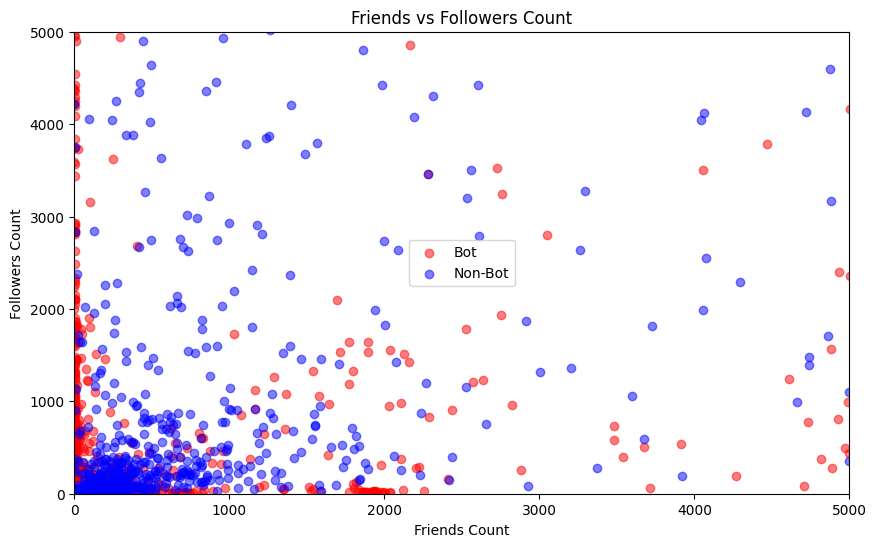

In [28]:
bots = df[df['bot'] == 1] 
non_bots = df[df['bot'] == 0] 


plt.figure(figsize=(10, 6))
plt.scatter(bots['friends_count'], bots['followers_count'], color='red', label='Bot', alpha=0.5)
plt.scatter(non_bots['friends_count'], non_bots['followers_count'], color='blue', label='Non-Bot', alpha=0.5)


plt.xlabel('Friends Count') 
plt.ylabel('Followers Count') 
plt.title('Friends vs Followers Count') 
plt.legend() 

plt.xlim(0, 5000)
plt.ylim(0, 5000)

plt.show()

In [21]:

bag_of_words = ['bot', 'follow me', 'free', 'fake', 'virus', 'troll', 'clone', 'tweet me'] 

def contains_bot_words(text):
    if pd.isna(text):
        return False
    
    text = str(text).lower()
    return any(word in text for word in bag_of_words)
    
df['screen_name_binary'] = df['screen_name'].apply(contains_bot_words)
df['name_binary'] = df['name'].apply(contains_bot_words) 
df['description_binary'] = df['description'].apply(contains_bot_words) 
df['status_binary'] = df['status'].apply(contains_bot_words) 


print(df[['screen_name', 'screen_name_binary']].head()) 

        screen_name  screen_name_binary
0  "HoustonPokeMap"               False
1         kernyeahx               False
2   mattlieberisbot                True
3         sc_papers               False
4      lucarivera16               False


In [22]:
feature_cols = [
    'friends_count', 
    'followers_count', 
    'screen_name_binary', 
    'name_binary', 
    'status_binary', 
    'verified', 
    'statuses_count'
] 
X = df[feature_cols] 
y = df['bot'] 

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [24]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn import metrics

clf = DecisionTreeClassifier(criterion='entropy') 
clf.fit(X_train, y_train)

train_pred = clf.predict(X_train)
test_pred = clf.predict(X_test) 

print("Training Accuracy:", metrics.accuracy_score(y_train, train_pred))
print("Testing Accuracy:", metrics.accuracy_score(y_test, test_pred)) 

print(export_text(clf, feature_names=list(X.columns))) 

Training Accuracy: 0.9994652406417113
Testing Accuracy: 0.8466334164588528
|--- verified <= 0.50
|   |--- friends_count <= 43.50
|   |   |--- statuses_count <= 59.50
|   |   |   |--- followers_count <= 0.50
|   |   |   |   |--- friends_count <= 39.50
|   |   |   |   |   |--- friends_count <= 12.50
|   |   |   |   |   |   |--- friends_count <= 9.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- friends_count >  9.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- friends_count >  12.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- friends_count >  39.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- followers_count >  0.50
|   |   |   |   |--- friends_count <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- friends_count >  0.50
|   |   |   |   |   |--- name_binary <= 0.50
|   |   |   |   |   |   |--- followers_count <= 8.00
|   |   |   |   |   |   |   |--- friends_count <= 8.00
|   |   |   |   |   |   |   |   |--- 

In [25]:
from sklearn.linear_model import LogisticRegression

clf_log = LogisticRegression()

clf_log.fit(X_train, y_train)

train_pred_log = clf_log.predict(X_train)
test_pred_log = clf_log.predict(X_test)

print("Logistic Regression Training Accuracy:", metrics.accuracy_score(y_train, train_pred_log))
print("Logistic Regression Testing Accuracy:", metrics.accuracy_score(y_test, test_pred_log))

Logistic Regression Training Accuracy: 0.7037433155080214
Logistic Regression Testing Accuracy: 0.6795511221945137


/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative s

In [32]:
# 1. No, at best we can say that bots with around 2000 friends and less than a hundred followers or so could be culled but 
# still won't get the majority of bots.
#
# 2. 
# Logistic Regression Training Accuracy: 0.7037433155080214
# Logistic Regression Testing Accuracy: 0.6795511221945137
#
# Training data is working with data the model has already seen, whereas the testing data is working with brand new accounts outside of
# the original training data
#
# 3. Decision Tree
# Most likely the relationship of statistics have a nonlinear logic that cannot be simply solved with a statistical analysis and requires
# A step based logic analysis.



In [35]:

clf_simple = DecisionTreeClassifier(criterion='entropy', max_depth=2)
clf_simple.fit(X_train, y_train)

train_pred_simple = clf_simple.predict(X_train)
test_pred_simple = clf_simple.predict(X_test) 

print("Training Accuracy:", metrics.accuracy_score(y_train, train_pred_simple))
print("Testing Accuracy:", metrics.accuracy_score(y_test, test_pred_simple)) 

print(export_text(clf_simple, feature_names=list(X.columns)))

Training Accuracy: 0.7903743315508022
Testing Accuracy: 0.7780548628428927
|--- verified <= 0.50
|   |--- friends_count <= 43.50
|   |   |--- class: 1
|   |--- friends_count >  43.50
|   |   |--- class: 0
|--- verified >  0.50
|   |--- friends_count <= 13643.00
|   |   |--- class: 0
|   |--- friends_count >  13643.00
|   |   |--- class: 0



In [37]:
# 4b. The Tree just checks if the account is verified, and then checks the friend count
#
# 4c. The most important statistic is the friends_count, but that is predicated on the verification status of the account


In [38]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

bot
0    0.528678
1    0.471322
Name: proportion, dtype: float64

In [41]:
# 5. 47% or so users are bots according to the classifier.
# If a dataset were only 10% bots, then you could just classify every user as not a bot and achieve 90% accuracy. An 85% accuracy 
# classifier would then be worse than the baseline test.
#
# 6. If the data is sorted, cutting out 30% of the data might shift means by a significant margin and put more weight on the leading 
# portion of data. This can be fixed by shuffling the data.
# 
# 7.
# Missing Data Threshold (35%)
# Which features to include in processing data (friends_count or verfied status)
# Keyword Selection in "bag of words"
# Entropy parameter
# max_depth

In [45]:
import random

X1s = [random.random() for _ in range(1000)]
X2s = [random.random() for _ in range(1000)] 

Ys = [1 if (x1 + x2 > 1) else 0 for x1, x2 in zip(X1s, X2s)] 

df_art = pd.DataFrame(data={'X1': X1s, 'X2': X2s, 'Y': Ys}) 

print(df_art.head())

         X1        X2  Y
0  0.399719  0.800174  1
1  0.525989  0.742542  1
2  0.745274  0.955936  1
3  0.594264  0.615290  1
4  0.651867  0.288827  0


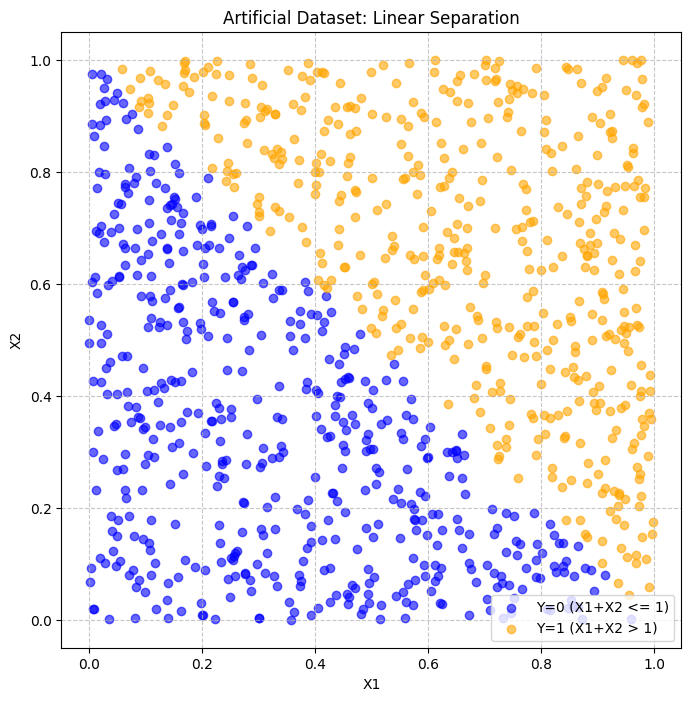

In [46]:
import matplotlib.pyplot as plt

class_0 = df_art[df_art['Y'] == 0]
class_1 = df_art[df_art['Y'] == 1]

plt.figure(figsize=(8, 8))

plt.scatter(class_0['X1'], class_0['X2'], color='blue', label='Y=0 (X1+X2 <= 1)', alpha=0.6)
plt.scatter(class_1['X1'], class_1['X2'], color='orange', label='Y=1 (X1+X2 > 1)', alpha=0.6)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Artificial Dataset: Linear Separation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_art = df_art[['X1', 'X2']]
y_art = df_art['Y']

dt_simple = DecisionTreeClassifier(criterion='entropy')
dt_simple.fit(X_art, y_art)
dt_acc = accuracy_score(y_art, dt_simple.predict(X_art))

lr_model = LogisticRegression()
lr_model.fit(X_art, y_art)
lr_acc = accuracy_score(y_art, lr_model.predict(X_art))

print(f"Decision Tree (depth=2) Accuracy: {dt_acc}")
print(f"Logistic Regression Accuracy: {lr_acc}")

Decision Tree (depth=2) Accuracy: 1.0
Logistic Regression Accuracy: 0.994


/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/benjaminding/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath

In [49]:
# 1. The dataset was created using a linear logic pattern (x1 + x2 > 1), therefore there existed a linear line where 
# a logistic regression function could easily find a solution.
#
# 2. 0.793 with max depth = 2
#
# 3. 1.0
#
# 4. The decision tree could just hardcode a decision case for every single edge point, and achieve a 100% accuracy result.